# 数据探查：互动易问答 (isqa)

路径：`/home/intern_fjq_2026/data/NLP/field_research/isqa_20240101_20241231.jsonl`

目标：彻底理解这份 **互动易 / 投资者问答(IR Q&A)** 数据的数据结构。

> 前 3 个逻辑 cell：`read_json` 加载 `df` → `df.head()` → 打印 `shape` 与 `columns`。


In [1]:
import pandas as pd

df = pd.read_json('/home/intern_fjq_2026/data/NLP/field_research/isqa_20240101_20241231.jsonl', lines=True)


In [2]:
df.head()


,S_INFO_WINDCODE,S_ASKDATE,S_ANSWERDATE,EVENT_ID,S_QUESTIONTYPE,S_QUESTIONCONTENT,S_ANSWERCONTENT,S_QUESTIONSOURCETYPE,QUESTION_PERSON,ANSWER_PERSON,ORIGINALWEBSITE
0,000002.SZ,20240101,20240112.0,None,259001000.0,请问其他应付款中的土地增值税清算准备金一般要到何时确认为实际应缴纳的土地增值税？若该项目后续...,谢谢您的关注，其他应付款中的土地增值税清算准备金是根据企业会计准则的要求、根据配比原则和谨慎...,269002000,花粑粑,万 科Ａ,http://irm.cninfo.com.cn/ircs/question/questio...
1,000002.SZ,20240101,NaN,None,259001000.0,我司泊寓、万纬物流的不动产以投资性房地产核算，酒店的不动产以固定资产核算，不知理解是否正确？,None,269002000,花粑粑,None,https://irm.cninfo.com.cn/ircs/question/questi...
2,000016.SZ,20240101,20240103.0,None,259007000.0,尊敬的董秘您好，请问公司到2023年底股东人数，谢谢,你好，谢谢你的关注。相关情况请关注本公司的定期报告。,269002000,股海钓鱼,深康佳Ａ,http://irm.cninfo.com.cn/ircs/question/questio...
3,000036.SZ,20240101,20240103.0,None,259002000.0,新增一个地产项目，包括拿地、获取开发权、建设投入、后续土增税将会掏空上市公司多年来积攒下来的...,谢谢关注。,269002000,irm17760897,华联控股,http://irm.cninfo.com.cn/ircs/question/questio...
4,000036.SZ,20240101,20240103.0,None,259002000.0,上市公司过往的投资实践已证明通过参与产业基金实现转型升级的方式并不可取，最终也不成功。请贵公...,谢谢关注。,269002000,irm17760897,华联控股,http://irm.cninfo.com.cn/ircs/question/questio...


In [3]:
print("shape:", df.shape)
print("columns:")
print(df.columns.tolist())


shape: (822253, 11)
columns:
['S_INFO_WINDCODE', 'S_ASKDATE', 'S_ANSWERDATE', 'EVENT_ID', 'S_QUESTIONTYPE', 'S_QUESTIONCONTENT', 'S_ANSWERCONTENT', 'S_QUESTIONSOURCETYPE', 'QUESTION_PERSON', 'ANSWER_PERSON', 'ORIGINALWEBSITE']


In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("DataFrame shape:", df.shape)
print("内存占用(deep): {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
time_cols   = ["S_ASKDATE", "S_ANSWERDATE"]
text_cols   = ["S_QUESTIONCONTENT", "S_ANSWERCONTENT"]
cat_cols    = ["S_QUESTIONTYPE", "S_QUESTIONSOURCETYPE"]
entity_cols = ["S_INFO_WINDCODE", "QUESTION_PERSON", "ANSWER_PERSON"]
url_cols    = ["ORIGINALWEBSITE"]
id_cols     = ["EVENT_ID"]

field_meaning = {
    "S_INFO_WINDCODE": "股票 Wind 代码",
    "S_ASKDATE": "提问日期",
    "S_ANSWERDATE": "回答日期",
    "EVENT_ID": "问答事件ID",
    "S_QUESTIONTYPE": "问题类型(编码)",
    "S_QUESTIONCONTENT": "问题正文",
    "S_ANSWERCONTENT": "回答正文",
    "S_QUESTIONSOURCETYPE": "问题来源类型(编码)",
    "QUESTION_PERSON": "提问人",
    "ANSWER_PERSON": "回答人",
    "ORIGINALWEBSITE": "原始链接",
}
pd.DataFrame({"字段含义": field_meaning}).reindex(df.columns)


DataFrame shape: (822253, 11)


内存占用(deep): 688.6 MB


,字段含义
S_INFO_WINDCODE,股票 Wind 代码
S_ASKDATE,提问日期
S_ANSWERDATE,回答日期
EVENT_ID,问答事件ID
S_QUESTIONTYPE,问题类型(编码)
S_QUESTIONCONTENT,问题正文
S_ANSWERCONTENT,回答正文
S_QUESTIONSOURCETYPE,问题来源类型(编码)
QUESTION_PERSON,提问人
ANSWER_PERSON,回答人


## 1. 字段类型 / 缺失 / 唯一值总览


In [5]:
# ============================================================
# 1. 字段类型 / 缺失 / 唯一值总览
# ============================================================
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
overview.sort_values(["null_pct", "n_unique"], ascending=[False, False])


,dtype,non_null,null,null_pct,n_unique
EVENT_ID,object,233672,588581,71.58,25803
ANSWER_PERSON,object,513043,309210,37.61,14016
QUESTION_PERSON,object,588672,233581,28.41,132628
S_ANSWERCONTENT,object,746323,75930,9.23,608808
S_ANSWERDATE,float64,746327,75926,9.23,577
ORIGINALWEBSITE,object,821247,1006,0.12,416255
S_QUESTIONTYPE,float64,821977,276,0.03,14
S_QUESTIONCONTENT,object,822253,0,0.00,671183
S_INFO_WINDCODE,object,822253,0,0.00,5443
S_ASKDATE,int64,822253,0,0.00,377


## 2. 主键 / 唯一性 / 重复


In [6]:
# ============================================================
# 2. 主键 / 唯一性 / 重复
# ============================================================
print("总行数:", len(df))
print("完全重复的行数 =", int(df.duplicated().sum()))
print("去掉 ID 列(如有)后仍完全重复的记录数 =", int(df.drop(columns=[c for c in ["EVENT_ID"] if c in df.columns]).duplicated().sum()))
print("EVENT_ID 非空 = %d，唯一值 = %d" % (
    int(df["EVENT_ID"].notna().sum()), df["EVENT_ID"].nunique()))

print("\n股票(Wind代码)唯一数 =", df["S_INFO_WINDCODE"].nunique())
print("Top20 被提问股票：")
print(df["S_INFO_WINDCODE"].value_counts().head(20).to_string())


总行数: 822253


完全重复的行数 = 257


去掉 ID 列(如有)后仍完全重复的记录数 = 8609
EVENT_ID 非空 = 233672，唯一值 = 25802

股票(Wind代码)唯一数 = 5443
Top20 被提问股票：


002270.SZ    4884
600207.SH    2399
300474.SZ    1569
300124.SZ    1269
000625.SZ    1182
000980.SZ    1148
600188.SH    1143
002254.SZ    1142
000661.SZ    1096
002042.SZ    1076
002449.SZ    1073
301413.SZ    1063
603025.SH    1056
600332.SH    1046
002138.SZ    1038
300142.SZ    1036
002008.SZ    1008
002405.SZ     995
301206.SZ     935
000063.SZ     928


## 3. 时间维度（提问 / 回答 日期）


S_ASKDATE  解析失败: 2456 | 范围: 2024-01-01 00:00:00 → 2024-12-31 00:00:00
S_ANSWERDATE 为空(未/暂无回答)行数: 78382
回答日期范围: 2024-01-01 00:00:00 → 2026-05-19 00:00:00

回答滞后天数(答-问): min/中位/均值/max = 0 / 1 / 7.2 / 778
count    743871.000000
mean          7.160438
std          23.619577
min           0.000000
25%           0.000000
50%           1.000000
75%           5.000000
max         778.000000
dtype: float64

按月提问量：
2024-01     59308
2024-02     42401
2024-03     70133
2024-04     96434
2024-05    117160
2024-06     58685
2024-07     53906
2024-08     75763
2024-09     64665
2024-10     56085
2024-11     70094
2024-12     55163
Freq: M, Name: S_ASKDATE, dtype: int64


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/pandas/core/tools/datetimes.py:1256: RuntimeWarning: invalid value encountered in cast
  masked_result = calc(carg[mask].astype(np.float64).astype(np.int64))


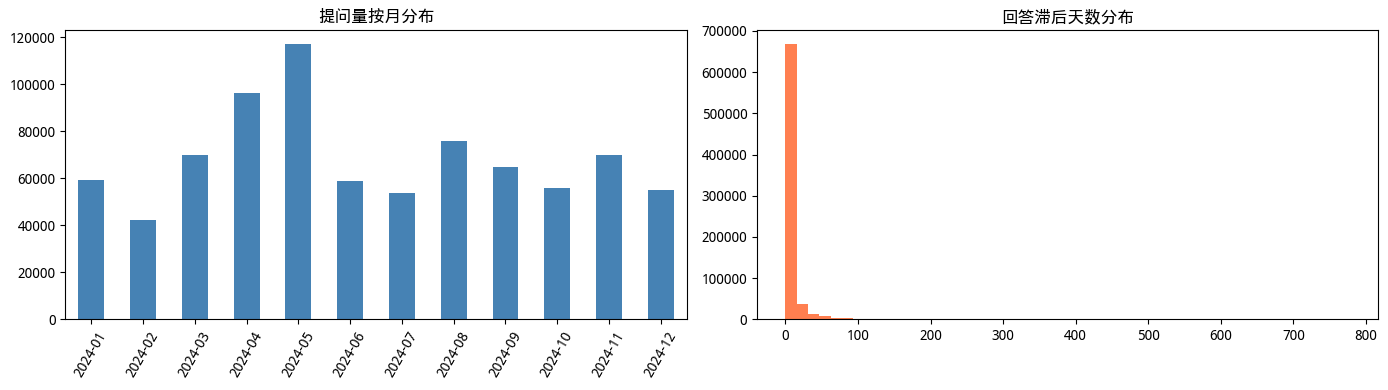

In [7]:
# ============================================================
# 3. 时间维度（提问 / 回答 日期）
# ============================================================
ask = pd.to_datetime(df["S_ASKDATE"], format="%Y%m%d", errors="coerce")
ans = pd.to_datetime(df["S_ANSWERDATE"], format="%Y%m%d", errors="coerce")
print("S_ASKDATE  解析失败:", int(ask.isna().sum()), "| 范围:", ask.min(), "→", ask.max())
print("S_ANSWERDATE 为空(未/暂无回答)行数:", int(ans.isna().sum()))
print("回答日期范围:", ans.min(), "→", ans.max())

lag_days = (ans - ask).dt.days
print("\n回答滞后天数(答-问): min/中位/均值/max = %.0f / %.0f / %.1f / %.0f" % (
    lag_days.min(), lag_days.median(), lag_days.mean(), lag_days.max()))
print(lag_days.describe())

monthly = ask.dt.to_period("M").value_counts().sort_index()
print("\n按月提问量：")
print(monthly)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("提问量按月分布")
axes[0].tick_params(axis="x", rotation=60)
axes[1].hist(lag_days.dropna(), bins=50, color="coral")
axes[1].set_title("回答滞后天数分布")
plt.tight_layout()
plt.show()


## 4. 文本字段（问题 / 回答 正文）


S_QUESTIONCONTENT 无缺失 = True | 长度 min/中位/均值/max = 1 / 31.0 / 45.6 / 1243

S_ANSWERCONTENT 非空 746323 / 822253，缺失 75930 (9.23%)


S_ANSWERCONTENT(非空) 长度：min/中位/均值/max = 1 / 92.0 / 130.4 / 5036



问题去重: 问题唯一值 671183 / 行数 822253，重复问题行数 = 151070


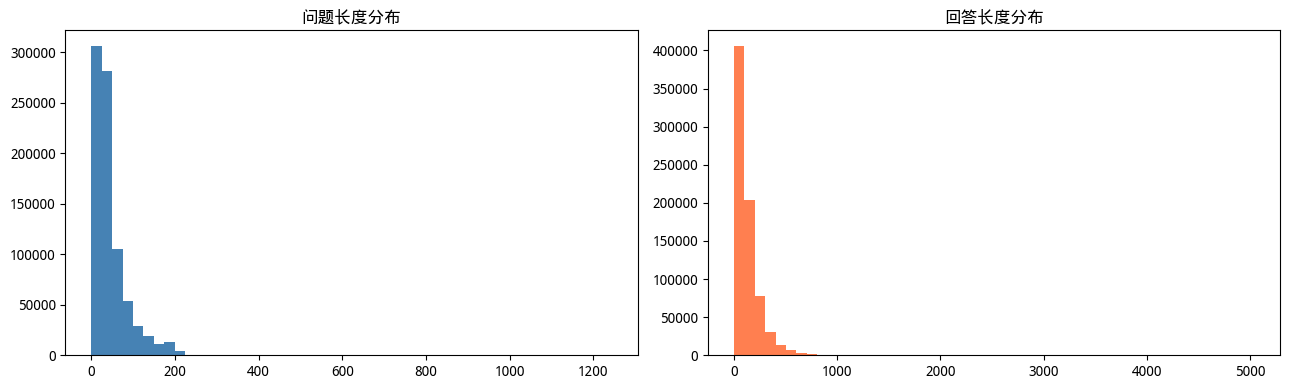


--- 最长回答样本 ---
index=151982, 股票=601998.SH, 问题=感谢管理层给我第一个提问机会,这个问题是提给董事长的,我记得去年贵行业绩发布会口号是“越向前,越精彩”,今年的业绩也在一定程度上兑现了您的指引,想问下董事长,过
谢谢你的持续关注，也谢谢你的问题。先回答前半个问题，刚才张青董秘已经对2023年中信银行的经营亮点进行了全方位展示，可以说刚才介绍的是我们中信银行36岁的全身照，用一句话概括，去年我们还是全面跑赢了大市。如果要再补充几句的话，我可以从经营的侧面来补点光。第一，在去年的整体形势下，在监管政策要求下，我们较好地统筹了支持实体经济和自身发展的需要，统筹了发展和风险，对实体经济支持力度在加大，“五篇大文章”起步开局有声有色，可以说我们在落实中央决策部署和中央金融工作会议精神方面，是有力有效的。第二，我们增效益的逻辑更加清晰，“稳息差、拓中收、稳质量”三大领域齐抓共治。我们没有把贷款的量和价作为提高营收的主渠道，而是通过压降存款成本来稳住息差，进而保证营收的增长，我们没有选择在贷款端“以价补量”或者“以量补价”，而是同时在存款端和提高非息收入方面下了很多功夫。第三，张青董秘介绍的数据背后，实际上是我们能力和体系建设的扎实推进与同步提升。我有一句自己想的话，“不体系，毋宁慢”，我们可以放慢发展速度，但是不能没有体系，所以我们特别注重体系建设，比如我们加速“新零售”转型，重塑公司业务竞争优势，纵深推进同业客户一体化经营，还有释放金市的投资交易能力，我们持续完善全面风险管理体系，不断提升科技的规划力、组织力和生产力。第四，难能可贵的是，我们过去“言必称他人好”，现在全行干部员工的自我认同感、组织归属感和责任使命感越来越强烈，队伍的信心和底气更足了。我认为，后两点相较于前两点更为硬核和厚重，既诠释了过去我们取得向上向好发展态势的原因，更为以后的高质量发展打下了非常好的基础。关于亮点，我就简单补充这么多，下面回答您后半个问题，关于对未来的展望。本行新一届班子已经经历了一个完整的规划期，即2021-2023年，经过三年努力，我们已经从“发展修复期”走过“能力构建期”，进入了“稳定发展期”，今年进入了第二个三年规划。前期我们在分析、研判内外部形势基础上，结合中信银行的特点，提出了新三年战略规划，明确要全面建设“四有银行”，跨入世界一流银行

In [8]:
# ============================================================
# 4. 文本字段（问题 / 回答 正文）
# ============================================================
qlen = df["S_QUESTIONCONTENT"].str.len()
print("S_QUESTIONCONTENT 无缺失 =", bool(df["S_QUESTIONCONTENT"].notna().all()),
      "| 长度 min/中位/均值/max = %d / %.1f / %.1f / %d" % (
          qlen.min(), qlen.median(), qlen.mean(), qlen.max()))

ans_content = df["S_ANSWERCONTENT"].dropna()
print("\nS_ANSWERCONTENT 非空 %d / %d，缺失 %d (%.2f%%)" % (
    len(ans_content), len(df),
    int(df["S_ANSWERCONTENT"].isna().sum()), df["S_ANSWERCONTENT"].isna().mean() * 100))
alen = ans_content.str.len()
print("S_ANSWERCONTENT(非空) 长度：min/中位/均值/max = %d / %.1f / %.1f / %d" % (
    alen.min(), alen.median(), alen.mean(), alen.max()))

print("\n问题去重: 问题唯一值 %d / 行数 %d，重复问题行数 = %d" % (
    df["S_QUESTIONCONTENT"].nunique(), len(df), int(df["S_QUESTIONCONTENT"].duplicated().sum())))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(qlen, bins=50, color="steelblue")
axes[0].set_title("问题长度分布")
axes[1].hist(alen, bins=50, color="coral")
axes[1].set_title("回答长度分布")
plt.tight_layout()
plt.show()

print("\n--- 最长回答样本 ---")
i = alen.idxmax()
print("index=%d, 股票=%s, 问题=%s" % (i, df.loc[i, "S_INFO_WINDCODE"], df.loc[i, "S_QUESTIONCONTENT"][:80]))
print(df.loc[i, "S_ANSWERCONTENT"][:1500])
print("\n--- 最短(非空)回答样本 ---")
j = alen.idxmin()
print("index=%d, 股票=%s" % (j, df.loc[j, "S_INFO_WINDCODE"]))
print(repr(df.loc[j, "S_ANSWERCONTENT"]))


## 5. 分类字段（问题类型 / 来源类型 编码）


S_QUESTIONTYPE  唯一值数=13
259001000.0    470213
259009000.0     95634
259007000.0     92019
259002000.0     86492
259013000.0     30590
259006000.0     22768
259003000.0      8005
259008000.0      6967
259004000.0      4084
259010000.0      3115
259005000.0      1868
NaN               276
259012000.0       178
259011000.0        44

S_QUESTIONSOURCETYPE  唯一值数=6
269002000    325403
269005000    249931
269001000    150957
269007000     61759
269006000     33927
269008000       276



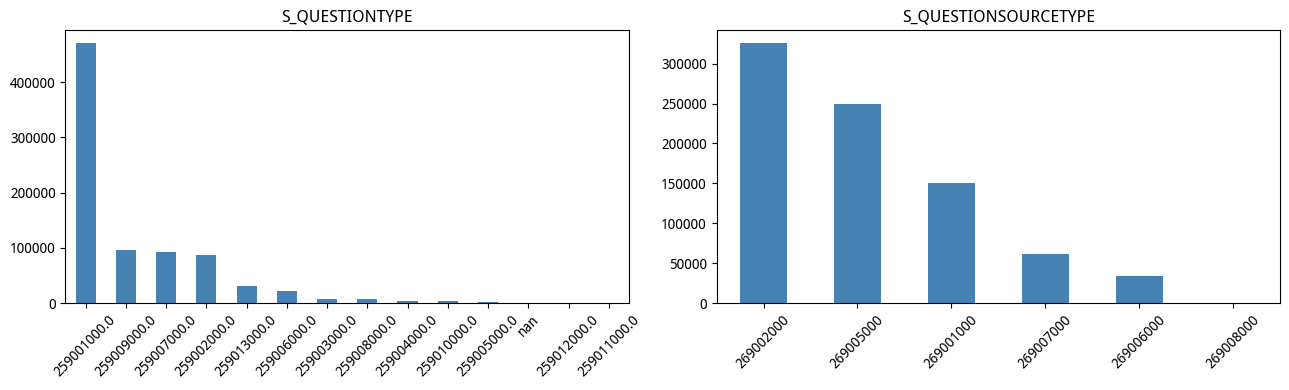

In [9]:
# ============================================================
# 5. 分类字段（问题类型 / 来源类型 编码）
# ============================================================
for c in cat_cols:
    print("=" * 70)
    print("%s  唯一值数=%d" % (c, df[c].nunique(dropna=True)))
    print(df[c].value_counts(dropna=False).head(20).to_string())
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, c in enumerate(cat_cols):
    df[c].value_counts(dropna=False).head(15).plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(c)
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. 提问人 / 回答人 分布


In [10]:
# ============================================================
# 6. 提问人 / 回答人 分布
# ============================================================
print("提问人去重人数 =", df["QUESTION_PERSON"].nunique())
print("提问人 Top20：")
print(df["QUESTION_PERSON"].value_counts().head(20).to_string())

print("\n回答人去重数 =", df["ANSWER_PERSON"].nunique())
print("回答人 Top20：")
print(df["ANSWER_PERSON"].value_counts(dropna=False).head(20).to_string())


提问人去重人数 = 132627
提问人 Top20：
guest_2VHJqeThm      9428
guest_zT0NfLL0L      8954
lalami               8597
破晓1988               8365
andy98001            4301
农夫钓鱼                 3152
irm113088838         2688
投资者_1695367685000    2388
irm117292761         2197
irm117285691         1960
投资者_1695375966000    1861
投资者_1695360109000    1828
投资者_1695366315000    1788
随风飘荡的时候              1668
andy98000            1285
cninfo450566         1275
guttymore            1160
投资者_1697014044000    1134
不知途远                  766
irm1911546            756

回答人去重数 = 14015
回答人 Top20：
None     309210
景嘉微        1208
四维图新        773
中兴通讯        742
三元生物        732
弘信电子        718
太极集团        715
国星光电        715
华孚时尚        707
王府井         686
中科创达        674
全 聚 德       665
众泰汽车        630
北汽蓝谷        622
隆华新材        613
南都电源        612
永泰能源        611
超捷股份        585
华如科技        575
长春高新        573


## 7. 原始链接


In [11]:
# ============================================================
# 7. 原始链接
# ============================================================
dom = df["ORIGINALWEBSITE"].dropna().str.extract(r"https?://([^/]+)", expand=False)
print("ORIGINALWEBSITE 域名 Top20：")
print(dom.value_counts(dropna=False).head(20).to_string())


ORIGINALWEBSITE 域名 Top20：
irm.cninfo.com.cn       325403
sns.sseinfo.com         243119
static.cninfo.com.cn     95223
ir.p5w.net               61757
www.cninfo.com.cn        47740
roadshow.sseinfo.com     33927
www.bse.cn                7710
www.sse.com.cn            5237
static.sse.com.cn          942
disc.static.szse.cn        173
NaN                         16


## 8. 字段交叉关系


In [12]:
# ============================================================
# 8. 字段交叉关系
# ============================================================
tmp = df.copy()
tmp["HAS_ANSWER"] = tmp["S_ANSWERCONTENT"].notna()
print("问题类型(S_QUESTIONTYPE) × 是否有回答：")
print(pd.crosstab(tmp["S_QUESTIONTYPE"], tmp["HAS_ANSWER"], margins=True))

print("\n问题来源类型(S_QUESTIONSOURCETYPE) × 是否有回答：")
print(pd.crosstab(tmp["S_QUESTIONSOURCETYPE"], tmp["HAS_ANSWER"], margins=True))

print("\n回答人(是否为空) 与 问题来源类型：")
print(pd.crosstab(tmp["S_QUESTIONSOURCETYPE"], tmp["ANSWER_PERSON"].notna(), margins=True))


问题类型(S_QUESTIONTYPE) × 是否有回答：
HAS_ANSWER      False    True     All
S_QUESTIONTYPE                       
259001000.0     43038  427175  470213
259002000.0      9759   76733   86492
259003000.0       861    7144    8005
259004000.0       411    3673    4084
259005000.0       167    1701    1868
259006000.0      3337   19431   22768
259007000.0      9897   82122   92019
259008000.0       583    6384    6967
259009000.0      7601   88033   95634
259010000.0         0    3115    3115
259011000.0         0      44      44
259012000.0         0     178     178
259013000.0         0   30590   30590
All             75654  746323  821977

问题来源类型(S_QUESTIONSOURCETYPE) × 是否有回答：


HAS_ANSWER            False    True     All
S_QUESTIONSOURCETYPE                       
269001000                 2  150955  150957
269002000             39485  285918  325403
269005000             36167  213764  249931
269006000                 0   33927   33927
269007000                 0   61759   61759
269008000               276       0     276
All                   75930  746323  822253

回答人(是否为空) 与 问题来源类型：
ANSWER_PERSON          False    True     All
S_QUESTIONSOURCETYPE                        
269001000             150943      14  150957
269002000              39485  285918  325403
269005000             118506  131425  249931
269006000                  0   33927   33927
269007000                  0   61759   61759
269008000                276       0     276
All                   309210  513043  822253


## 9. 原始数据抽样查看


In [13]:
# ============================================================
# 9. 原始数据抽样查看
# ============================================================
sample = df.sample(n=3, random_state=42)
for i, (idx, row) in enumerate(sample.iterrows(), 1):
    print("=" * 80)
    print("样本 %d / 3   (原始 index=%d)" % (i, idx))
    print("-" * 80)
    for col in df.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "  ......[截断]"
        print("%-22s : %s" % (col, val))
    print()


样本 1 / 3   (原始 index=698194)
--------------------------------------------------------------------------------
S_INFO_WINDCODE        : 300346.SZ
S_ASKDATE              : 20241101
S_ANSWERDATE           : nan
EVENT_ID               : None
S_QUESTIONTYPE         : 259002000.0
S_QUESTIONCONTENT      : 董秘您好：现在管理层出台了一系列政策，鼓励企业并购重组完善上下游产业链和做大做强。不单单做大做强了自身 借着市场好补充了流动性，也做到了股东和上市公司双赢。如果有合适的标的，公司是否会进行并购重组或者引入战略投资者，利用好当下资本市场的政策，做大做强自身与股东共赢？谢谢。
S_ANSWERCONTENT        : None
S_QUESTIONSOURCETYPE   : 269002000
QUESTION_PERSON        : 星空守望者
ANSWER_PERSON          : None
ORIGINALWEBSITE        : https://irm.cninfo.com.cn/ircs/question/questionDetail?questionId=1852842390140157952

样本 2 / 3   (原始 index=459873)
--------------------------------------------------------------------------------
S_INFO_WINDCODE        : 002985.SZ
S_ASKDATE              : 20240709
S_ANSWERDATE           : 20240729.0
EVENT_ID               : None
S_QUESTIONTYPE         : 259001000.0
S_QUESTIONCONTENT      : 公司二季度大量产品无法实现销售，是否

## 10. 结论摘要（自动汇总）


In [14]:
# ============================================================
# 10. 结论摘要（自动汇总）
# ============================================================
ask_dt = pd.to_datetime(df["S_ASKDATE"], format="%Y%m%d", errors="coerce")
ans_dt = pd.to_datetime(df["S_ANSWERDATE"], format="%Y%m%d", errors="coerce")
lines = []
lines.append("文件: /home/intern_fjq_2026/data/NLP/field_research/isqa_20240101_20241231.jsonl")
lines.append("总记录数: %d 行 × %d 列" % df.shape)
lines.append("提问日期范围: %s ~ %s" % (ask_dt.min(), ask_dt.max()))
lines.append("回答日期范围: %s ~ %s" % (ans_dt.min(), ans_dt.max()))
lines.append("完全重复行: %d" % int(df.duplicated().sum()))
lines.append("股票(Wind代码) %d 只；提问人 %d；回答人 %d" % (
    df["S_INFO_WINDCODE"].nunique(), df["QUESTION_PERSON"].nunique(),
    df["ANSWER_PERSON"].nunique()))
lines.append("回答正文缺失率: %.2f%%" % (df["S_ANSWERCONTENT"].isna().mean()*100))
lines.append("问题类型取值: %s" % sorted(df["S_QUESTIONTYPE"].dropna().unique().tolist()))
lines.append("问题来源类型取值: %s" % sorted(df["S_QUESTIONSOURCETYPE"].dropna().unique().tolist()))
lines.append("回答滞后(答-问) 中位天数: %.0f" % (ans_dt - ask_dt).dt.days.median())
print("\n".join(lines))


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/pandas/core/tools/datetimes.py:1256: RuntimeWarning: invalid value encountered in cast
  masked_result = calc(carg[mask].astype(np.float64).astype(np.int64))


文件: /home/intern_fjq_2026/data/NLP/field_research/isqa_20240101_20241231.jsonl
总记录数: 822253 行 × 11 列
提问日期范围: 2024-01-01 00:00:00 ~ 2024-12-31 00:00:00
回答日期范围: 2024-01-01 00:00:00 ~ 2026-05-19 00:00:00
完全重复行: 257
股票(Wind代码) 5443 只；提问人 132627；回答人 14015
回答正文缺失率: 9.23%
问题类型取值: [259001000.0, 259002000.0, 259003000.0, 259004000.0, 259005000.0, 259006000.0, 259007000.0, 259008000.0, 259009000.0, 259010000.0, 259011000.0, 259012000.0, 259013000.0]
问题来源类型取值: [269001000, 269002000, 269005000, 269006000, 269007000, 269008000]
回答滞后(答-问) 中位天数: 1
